Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menu bar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menu bar, select Cell$\rightarrow$Run All).


Below, please fill in your name and collaborators, if any:

In [1]:
NAME = "Cameron Turner"
COLLABORATORS = ""

# Assignment 4 - Classification

In this assignment, you will practice using the kNN (k-Nearest Neighbors) algorithm to solve a classification problem.
The kNN is a simple and robust classifier, which is used in different applications.

We will use the Iris dataset for this assignment.
The dataset was first introduced by statistician R. Fisher and consists of 50 observations from each of three species Iris (_Iris setosa_, _Iris virginica_ and _Iris versicolor_). For each sample, 4 features are given: the sepal length and width, and the petal length and width.

The goal is to train kNN algorithm to distinguish the species from one another.

1. The dataset can be downloaded from UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/.

2. Download `iris.data` file from the Data Folder. The Data Set description with the definitions of all the columns can be found on the dataset page - https://archive.ics.uci.edu/ml/datasets/Iris. Alternatively, you can import the data using sklearn.datasets. You will need to dowload both the sepal/petal data and the target variable information, then merge the two datasets.

3. _(1 points)_ Load the data from the file (`iris.data`) into the DataFrame. Set the names of columns according to the column definitions given in Data Description.

4. _(2 points)_ **Data inspection.** 
    - Display the first 5 rows of the dataset and use any relevant functions that can help you to understand the data.
    - Prepare 2 scatter plots - `sepal_width` vs `sepal_length` and `petal_width` vs `petal_length`. Scatter plots should show each class in different color (`seaborn.lmplot` is recommended for plotting). 

5. _(2 points)_ **Prepare the data for classification**. 
    - Using the pandas operators prepare the feature variables `X` and the response `Y` for the fit. Note that `sklean` expects data as arrays, so convert extracted columns into arrays.

6. _(1 point)_ **Split** the data into `train` and `test` using `sklearn` `train_test_split` function.

7. _(2 points)_ **Run the fit** using `KNeighborsClassifier` from `sklearn.neighbors`. 
    - First, instantiate the model,
    - Then, run the classifier on the training set.

8. _(3 points)_ Use learning model to **predict the class from features**, run prediction on `X` from test part. 
    - Show the **accuracy score** of the prediction by comparing predicted iris classes and the `Y` values from the test.
    - Comparing these two arrays (predicted classes and test `Y`), count the numbers of correct predictions and predictions that were wrong. (**HINTS:** `NumPy` arrays can be compared using `==` operator. You can also use `NumPy`'s operator `count_nonzero` to count number of non-False values).

9. _(4 points)_ In this task, we want to see how accuracy score and the number of correct predictions change with the number of neighbors `k`. We will use the following **number of neighbors `k`: 1, 3, 5, 7, 10, 20, 30, 40, and 50**:
    - Generate 10 random train/test splits for each value of `k`
    - Fit the model for each split and generate predictions
    - Average the accuracy score for each `k`
    - Calculate the average number of correct predictions for each `k` as well
    - Plot the accuracy score for different values of `k`. What conclusion can you make based on the graph?


In [2]:
## TYPE YOUR CODE HERE

In [3]:
# Import libraries.
#
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris


# Class: KNN_Classification
#
class KNN_Classification:
    
    # Constructor.
    #
    def __init__(self, debug=False):
        
        # Set the attributes.
        #
        self.debug = debug
        
    
    # load_data
    #
    def load_data(self):
        
        iris_target_names_dict = {0 : 'setosa', 1 : 'versicolor', 2 : 'virginica'}
        iris = load_iris()
        
        # Iris splits the iris records into its data and target components.
        #
        data = iris.data
        target = iris.target
        
        # Create the Dataframes.
        #
        df_data = pd.DataFrame(data,columns=['sepal_length','sepal_width','petal_length','petal_width'])
        self.df_target = pd.DataFrame(target,columns=['target'])
        self.df_all = pd.concat([df_data, self.df_target], axis=1)

        # Create a Dataframe based on a copy of the 'all' data frame (data + target) 
        # and add a new field called species_name.  This Dataframe is just to classify data
        # based on the more user-friendly species name rather than a target integer value.
        #
        self.df_all_name = self.df_all.copy()
        self.df_all_name['species_name'] = self.df_all_name['target'].map(iris_target_names_dict)

        # Prepare the classification data.
        #
        self.prepare_classification()

        # Print out debug statements.
        #
        if self.debug:
            
            # Display information.
            #
            print("\n***Target Names")
            print(iris.target_names)
            print("---------------")
            print("\n***Aggregate Dataframe")
            print(self.df_all)
            print("---------------")

        print("Iris data has been loaded.")
    
    
    # get_dataframe_all
    #
    def get_dataframe_all(self):
        
        return self.df_all
    
    
    # plot_scatter_plot
    #
    def plot_scatter_plot(self, plot_title, df, column_x, column_y, colour_column):
        
        # Plot the scatter plot using Seaborn and the specified dataframe, x and y
        # columns and separate by values in the colour_column.
        #
        sns.lmplot(x = column_x, y = column_y, data = df, hue=colour_column).set(title=plot_title)

        # Now plot the same scatter plot except don't separate by values in the colour_column
        # to plot an aggregate between all data regardless of the column on which to base
        # the colour (e.g., species name).
        #
        sns.lmplot(x = column_x, y = column_y, data = df).set(title=plot_title)
 
        # Display the scatter plot.
        #
        plt.show()        
        
        
    # identify_incomplete_column_data
    #
    def identify_incomplete_column_data(self):
        
        # Print out the columns with null values along with how many records
        # are null for each column.
        #
        print ('----------------------------')
        print (self.df_all.isnull().sum())
        print ('----------------------------')

        
    # print_data
    #    
    def print_data(self):
        
        # Print out general information about the data.
        #
        print ('\nSome general information about the dataset:\n')
        print ('----------------------------')
        print ('Total number of data elements: \t', self.df_all_name.loc[:, 'target'].shape[0])
        print ('setosa data: \t\t\t', self.df_all_name[(self.df_all_name['species_name'] == 'setosa')].shape[0])
        print ('versicolor data: \t\t', self.df_all_name[(self.df_all_name['species_name'] == 'versicolor')].shape[0])
        print ('virginica data: \t\t', self.df_all_name[(self.df_all_name['species_name'] == 'virginica')].shape[0])
        print ('----------------------------')


    # calculate_species_agg
    #        
    def calculate_species_agg(self, species_attribute, agg_func):
        
        # Create a pivot table based on the group arguments (e.g., species_name) and the
        # pivot_value (e.g., sepal_length).  Calculate the mean and sort the values in 
        # descending order.
        #
        p_df = self.df_all_name.pivot_table(index='species_name', values=species_attribute, aggfunc=agg_func).sort_values(by='species_name', ascending=True)

        print ('---------', agg_func, '-------------------')
        print (p_df)
        print ('----------------------------\n')
        
        # Plot a barchart of the dataframe.
        #
        self.plot_barchart(p_df)   

        
    # plot_barchart
    #
    def plot_barchart(self, df):
        
        # Plot the dataframe as a bar chart.
        #
        ax = df.plot.bar(rot=0)

        
    # plot_scatter_matrix
    #
    def plot_scatter_matrix(self):
    
        # Plot the bar graph by mean.
        #
        pd.plotting.scatter_matrix(self.df_all, alpha=0.2, figsize=(10,10))

        
    # make_knn_predictions
    #
    def make_knn_predictions(self, k_neighbours_list, training_test_size=20, 
                             number_of_test_cases=10):

        # Ensure that the training test size is not larger than the number of samples in the
        # data set.
        #
        assert training_test_size < self.Y.shape[0], ("Training test size must be less than ", self.Y.shape[0])
        
        # Initialize the prediction dictionary.
        #
        k_neighbours_prediction_dict = {}
        index = 0

        # Iterate over the list of neighbours.
        #
        for neighbour in k_neighbours_list:

            k_correct_predictions = 0
            k_accuracy = 0
    
            print ("\nExamining K nearest neighbour", neighbour)
        
            # Run the test based on the number_of_test_cases specified.
            #
            for test in range(number_of_test_cases):
    
                # Invoke the process:
                #
                #   1. Split data into training and test data
                #   2. Invoke the Machine Learning algorithm
                #   3. Make the prediction
                #   4. Record the accuracy of the prediction
                #
                self.split_data_into_training_and_test(training_test_size)
                self.invoke_knn_algorithm(neighbour)
                my_prediction_results = self.make_prediction()
        
                # Calculate the correct number of predictions and the accuracy.
                #
                correct_predictions = np.count_nonzero(my_prediction_results)
        
                accuracy = (correct_predictions / training_test_size) * 100
                print ("\tTest", test, ": Correct predictions =", correct_predictions, "/", training_test_size, 
                       "Incorrect predictions =", (training_test_size - correct_predictions), "Accuracy = ", accuracy)
        
                # Add the correct predictions and accuracy to the total accuracy for this k-test.
                #
                k_correct_predictions += correct_predictions
                k_accuracy += accuracy
        
            # Print out correct number of predictions and accuracy.
            #
            print ("For K nearest neighbour", neighbour, "the average correct predictions is", k_correct_predictions / number_of_test_cases, "/", training_test_size)
            print ("For K nearest neighbour", neighbour, "the accuracy is", k_accuracy / number_of_test_cases, "%")

            # Create a list with the k neighbour and its accuracy.
            #
            k_list = [ neighbour, k_accuracy / number_of_test_cases]
            
            # Add the k_list to the dictionary at the current index.
            #
            k_neighbours_prediction_dict[index] = k_list
            
            # Increment the index.
            #
            index += 1
    
        # Set the column names that can be combined with the k neighbours dictionary for
        # conversion to a dataframe.
        #
        column_names = ['k_neighbour', 'accuracy_score']

        # Convert the k neighbours prediction dictionary to a Dataframe and return it.
        #
        return pd.DataFrame.from_dict(k_neighbours_prediction_dict, orient='index', columns= column_names)
        
        
    # prepare_classification
    #
    def prepare_classification(self):
        
        # Set the X and Y parameters.  The X value (input) is based on the column 
        # data (except the 'target' column) and the Y value (output) are the target 
        # values (i.e., type of iris).
        #
        self.X = self.df_all.drop(['target'], axis=1) 
        self.Y = self.df_target.values 

        # Print out debug statements.
        #
        if self.debug:

            print ("\n***X Input Values")
            print (self.X)
            print ("-------------------")
            print ("\Y Output Values")
            print (self.Y)
            print ("-------------------")


    # split_data_into_training_and_test
    #
    def split_data_into_training_and_test(self, training_test_size=10):
        
        # Split data into training and test lists.  Use the training test size
        # which needs to be less than the size of the test data.
        #
        # Note: use a random_state=None to change the training and test data 
        # each time.  A random_state=<int> will create the same training and test
        # data for each split for that <int> so each <int> will result in a different 
        # training and test dataset (e.g., random_state=0 will create one training and
        # test dataset while random_state=1 will create a different training and test
        # dataset.
        #
        self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(
            self.X, self.Y, test_size=training_test_size, random_state=None)
        
        if self.debug:
        
            print ("\n*** X Training Data")
            print (self.x_train)
            print ("-------------------")
            print ("\n*** X Test Data")
            print (self.x_test)
            print ("-------------------")
            print ("\n*** Y Training Data")
            print (self.y_train)
            print ("-------------------")
            print ("\n*** Y Test Data")
            print (self.y_test)
            print ("-------------------")

            
    # invoke_knn_algorithm
    #
    def invoke_knn_algorithm(self, neighbours=3):

        # Create the K-Neighbours Classifier model with the number of neighbours
        # to use in the model.  Fit the input training data (X) and the output
        # training data (Y).
        #
        self.knn = KNeighborsClassifier(n_neighbors=neighbours)
        self.knn.fit(self.x_train, self.y_train.ravel())
        
    
    # make_prediction
    #
    def make_prediction(self):
        
        # Get the prediction (Y) using the input (X) test data.
        #
        y_prediction = self.knn.predict(self.x_test)
        
        if self.debug:

            # Print out the prediction along with the actual Y test data.
            #
            print("Prediction  = ", y_prediction)
            print("Y Test data = ", self.y_test.ravel())
        
        # Reshape the Y test data in order to compare it to the prediction results.
        #
        self.y_test = np.reshape(self.y_test, (self.y_test.size,))
        
        # Compare the prediction results with the actual Y test data to get 
        # which ones were a correct prediction.
        #
        prediction_results = (y_prediction == self.y_test)

        return prediction_results
    
        

In [4]:
# Main
#

# Part 3:
#
# Instantiate the class and load the iris data.  Note: the argument, False, is just to turn
# debugging off.
#
my_classifier = KNN_Classification(False)
my_classifier.load_data()


Iris data has been loaded.


In [5]:
# Part 4
#
# As a best practice, identify if there are any missing data to ensure the dataset is complete.
#
my_classifier.identify_incomplete_column_data()

# Observation: all columns are populated.  Therefore, the dataset is complete.
#

----------------------------
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
dtype: int64
----------------------------


In [6]:
# Part 4
#

# Get the dataframe that contains all data.
#
df = my_classifier.get_dataframe_all()

# Print out the first 5 rows.
#
df.head()

# Observation: data in this dataset are predominantly floats.
#

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
# Part 4
#

# Print out some general information about the dataset.
#
my_classifier.print_data()

# Observation: there are equal number of records for each species.  Therefore, the 
# different iris data should be equally (relatively) represented in the training and test data.
# This should help reduce bias in the data (i.e., one species is not over-represented).
#


Some general information about the dataset:

----------------------------
Total number of data elements: 	 150
setosa data: 			 50
versicolor data: 		 50
virginica data: 		 50
----------------------------


--------- mean -------------------
              sepal_length
species_name              
setosa               5.006
versicolor           5.936
virginica            6.588
----------------------------

--------- mean -------------------
              sepal_width
species_name             
setosa              3.428
versicolor          2.770
virginica           2.974
----------------------------

--------- mean -------------------
              petal_length
species_name              
setosa               1.462
versicolor           4.260
virginica            5.552
----------------------------

--------- mean -------------------
              petal_width
species_name             
setosa              0.246
versicolor          1.326
virginica           2.026
----------------------------



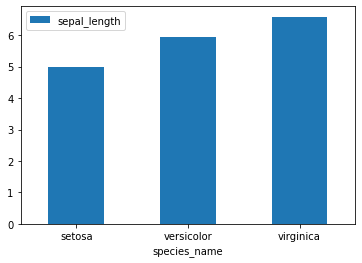

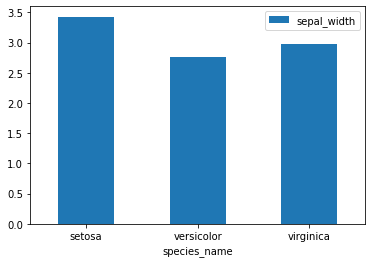

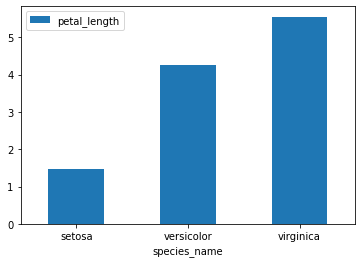

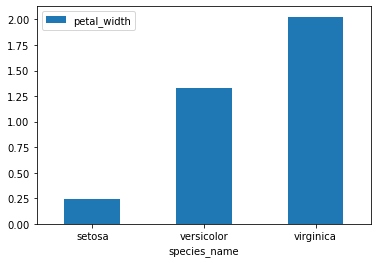

In [8]:
# Part 4
#

# In order to get a general comprehension of the dataset, calculate the mean, max and min
# values for each of the species by sepal_length, sepal_width, petal_length and
# petal_width.  This most likely will not have any bearing on the classifications and predictions
# whatsoever but it does lead to a better understanding of the data and knowledge domain.
#

# Calculate mean information on the different attributes of the species.
#
my_classifier.calculate_species_agg('sepal_length', 'mean')
my_classifier.calculate_species_agg('sepal_width', 'mean')
my_classifier.calculate_species_agg('petal_length', 'mean')
my_classifier.calculate_species_agg('petal_width', 'mean')

# Observation: virginica is the largest iris and setosa is the smallest.  Except for sepal_width
# in which case setosa is the largest.  That is curious!  It made me look up pictures of these
# types of iris to see what they look like and now I see why setosas have the widest sepals. 
#

--------- max -------------------
              sepal_length
species_name              
setosa                 5.8
versicolor             7.0
virginica              7.9
----------------------------

--------- max -------------------
              sepal_width
species_name             
setosa                4.4
versicolor            3.4
virginica             3.8
----------------------------

--------- max -------------------
              petal_length
species_name              
setosa                 1.9
versicolor             5.1
virginica              6.9
----------------------------

--------- max -------------------
              petal_width
species_name             
setosa                0.6
versicolor            1.8
virginica             2.5
----------------------------



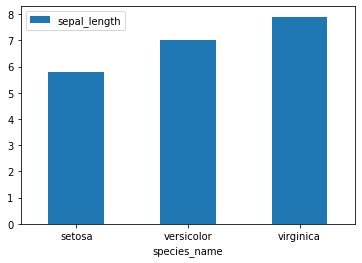

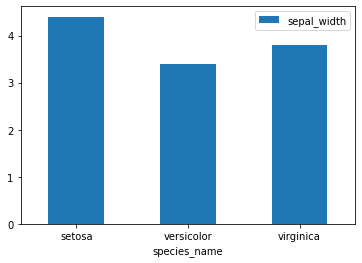

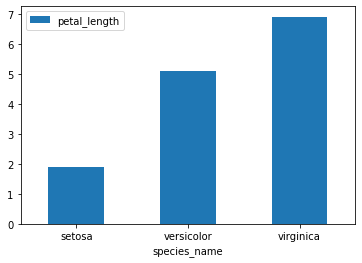

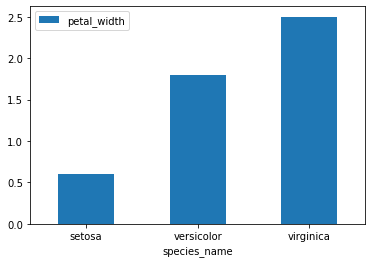

In [9]:
# Part 4
#

# Calculate max information on the different attributes of the species.
#
my_classifier.calculate_species_agg('sepal_length', 'max')
my_classifier.calculate_species_agg('sepal_width', 'max')
my_classifier.calculate_species_agg('petal_length', 'max')
my_classifier.calculate_species_agg('petal_width', 'max')

# Observation: virginica has the largest iris attributes and setosa has the smallest,  
# except for sepal_width in which case setosa has the largest value.  This is to be expected
# as setosas had the largest average sepal widths from the previous mean calculations.
#

--------- min -------------------
              sepal_length
species_name              
setosa                 4.3
versicolor             4.9
virginica              4.9
----------------------------

--------- min -------------------
              sepal_width
species_name             
setosa                2.3
versicolor            2.0
virginica             2.2
----------------------------

--------- min -------------------
              petal_length
species_name              
setosa                 1.0
versicolor             3.0
virginica              4.5
----------------------------

--------- min -------------------
              petal_width
species_name             
setosa                0.1
versicolor            1.0
virginica             1.4
----------------------------



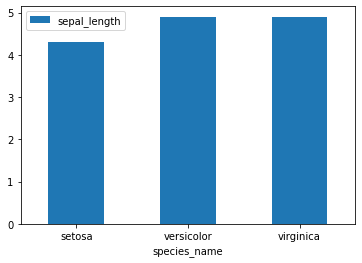

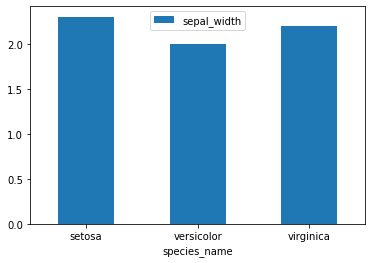

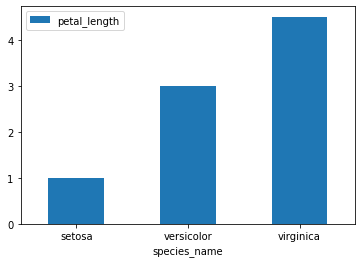

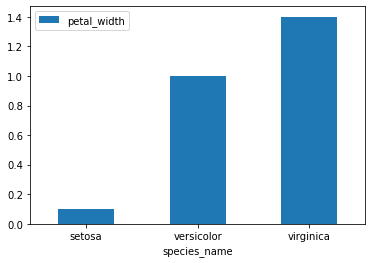

In [10]:
# Part 4
#

# Calculate min information on the different attributes of the species.
#
my_classifier.calculate_species_agg('sepal_length', 'min')
my_classifier.calculate_species_agg('sepal_width', 'min')
my_classifier.calculate_species_agg('petal_length', 'min')
my_classifier.calculate_species_agg('petal_width', 'min')

# Observation: setosa has the smallest iris attributes and virginica has the largest minimum 
# value, except for sepal_width in which case setosa has the largest value.  Once again, this is
# to be expected given the previous mean and max calculations.
#

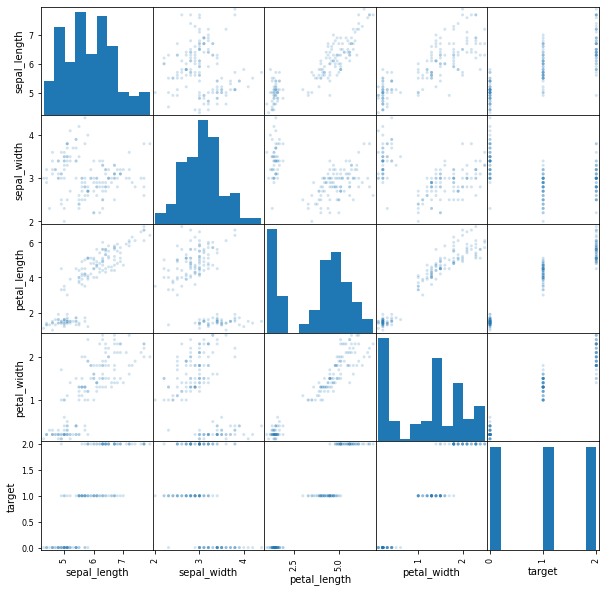

In [11]:
# Part 4
#

# To continue to get a better sense of the data, use a scatter matrix to do scatter
# plots of the field pairs to see if there are any potential correlations.
#

# Plot a scatter matrix of the data.
#
my_classifier.plot_scatter_matrix()

# Observation: there looks like there is a positive correlation between petal_length and
# petal_width.  Possibly a positive correlation between petal_length and sepal_length.
#

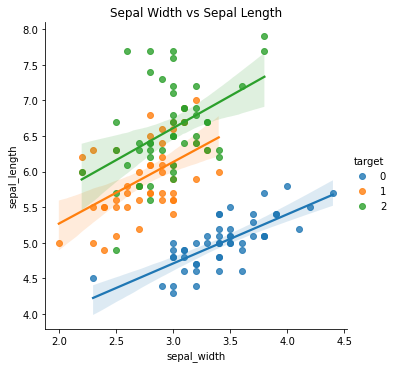

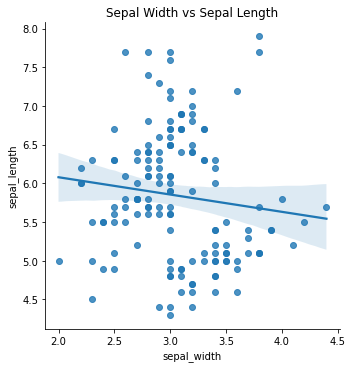

In [12]:
# Part 4
#

# Get the dataframe that contains all data.
#
df = my_classifier.get_dataframe_all()

# Plot a scatter plot based on sepal width and sepal length.
#
my_classifier.plot_scatter_plot("Sepal Width vs Sepal Length", df, 'sepal_width', 'sepal_length', 'target')

# Observation: there are two diagrams below.  When the data is grouped by species (target) in
# the first diagram, there appears to be better positive correlation between the sepal width and 
# sepal length.  When the data is grouped as a whole, there doesn't appear to be a strong
# correlation, even though a negative correlation is shown.
#

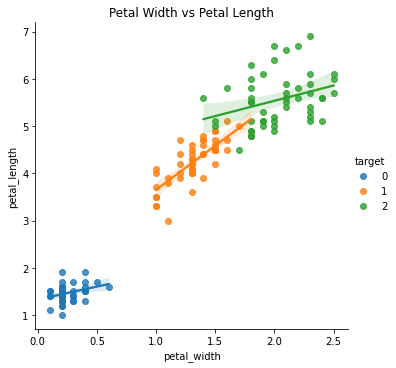

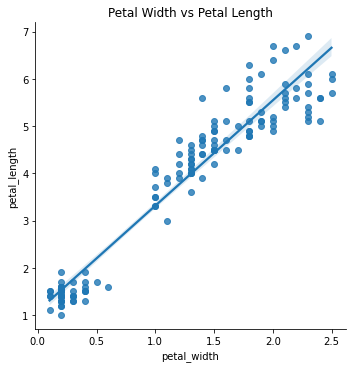

In [13]:
# Part 4
#

# Get the dataframe that contains all data.
#
df = my_classifier.get_dataframe_all()

# Plot a scatter plot based on petal width and petal length.
#
my_classifier.plot_scatter_plot("Petal Width vs Petal Length", df, 'petal_width', 'petal_length', 'target')

# Observation: there seems to be a positive correlation between petal width and petal length 
# when the data is grouped by species (target) as well as when the data is grouped as a whole.
# This correlation was not observed with sepal width and sepal length when the data was 
# grouped as a whole.  This positive correlation seems to match up with the findings from 
# the scatter matrix.
#


Examining K nearest neighbour 1
	Test 0 : Correct predictions = 19 / 20 Incorrect predictions = 1 Accuracy =  95.0
	Test 1 : Correct predictions = 20 / 20 Incorrect predictions = 0 Accuracy =  100.0
	Test 2 : Correct predictions = 20 / 20 Incorrect predictions = 0 Accuracy =  100.0
	Test 3 : Correct predictions = 19 / 20 Incorrect predictions = 1 Accuracy =  95.0
	Test 4 : Correct predictions = 20 / 20 Incorrect predictions = 0 Accuracy =  100.0
	Test 5 : Correct predictions = 20 / 20 Incorrect predictions = 0 Accuracy =  100.0
	Test 6 : Correct predictions = 19 / 20 Incorrect predictions = 1 Accuracy =  95.0
	Test 7 : Correct predictions = 20 / 20 Incorrect predictions = 0 Accuracy =  100.0
	Test 8 : Correct predictions = 18 / 20 Incorrect predictions = 2 Accuracy =  90.0
	Test 9 : Correct predictions = 18 / 20 Incorrect predictions = 2 Accuracy =  90.0
For K nearest neighbour 1 the average correct predictions is 19.3 / 20
For K nearest neighbour 1 the accuracy is 96.5 %


    k_neig

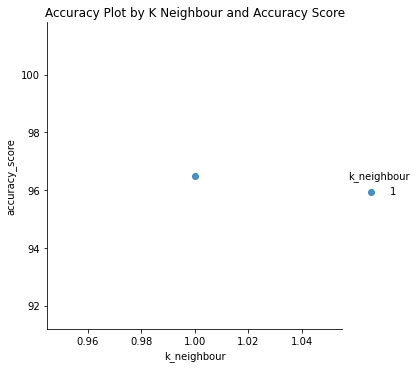

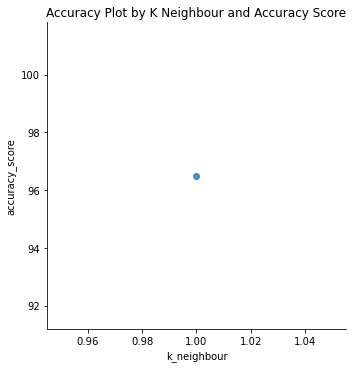

In [14]:
# Part 5 - 9
#

# Small Test Case
#
# This is the small test case based on:
#
#   - Prediction based on 1 k nearest neighbour,
#   - 10 test cases 
#   - training test size of 20.
#

# Set up the list of k nearest neighbours for the KNN model under test.
#
k_neighbours_list = [1]

# Set the ML training test size, the number of test cases with which each k 
# nearest neighbour will be tested.
#
training_test_size = 20
number_of_test_cases = 10

df = my_classifier.make_knn_predictions(k_neighbours_list, training_test_size, 
                                        number_of_test_cases)

# Display the dataframe.
#
print ("\n\n", df)

# Plot the dataframe using the k_neighbour and accuracy_score columns.
#
my_classifier.plot_scatter_plot('Accuracy Plot by K Neighbour and Accuracy Score', df, 'k_neighbour', 'accuracy_score', 'k_neighbour')

# Observation: when the training test size is small (20), the accuracy is very high (96.5%).
# Note that numbers may differ based on each individual execution.
#


Examining K nearest neighbour 1
	Test 0 : Correct predictions = 96 / 100 Incorrect predictions = 4 Accuracy =  96.0
	Test 1 : Correct predictions = 97 / 100 Incorrect predictions = 3 Accuracy =  97.0
	Test 2 : Correct predictions = 92 / 100 Incorrect predictions = 8 Accuracy =  92.0
	Test 3 : Correct predictions = 95 / 100 Incorrect predictions = 5 Accuracy =  95.0
	Test 4 : Correct predictions = 96 / 100 Incorrect predictions = 4 Accuracy =  96.0
	Test 5 : Correct predictions = 95 / 100 Incorrect predictions = 5 Accuracy =  95.0
	Test 6 : Correct predictions = 95 / 100 Incorrect predictions = 5 Accuracy =  95.0
	Test 7 : Correct predictions = 96 / 100 Incorrect predictions = 4 Accuracy =  96.0
	Test 8 : Correct predictions = 95 / 100 Incorrect predictions = 5 Accuracy =  95.0
	Test 9 : Correct predictions = 93 / 100 Incorrect predictions = 7 Accuracy =  93.0
For K nearest neighbour 1 the average correct predictions is 95.0 / 100
For K nearest neighbour 1 the accuracy is 95.0 %


    

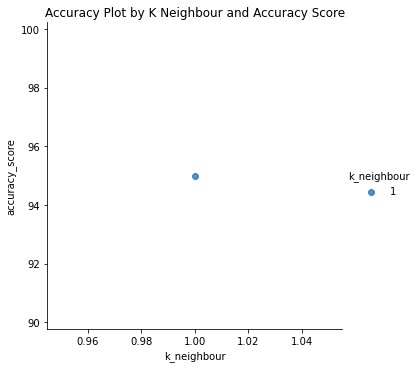

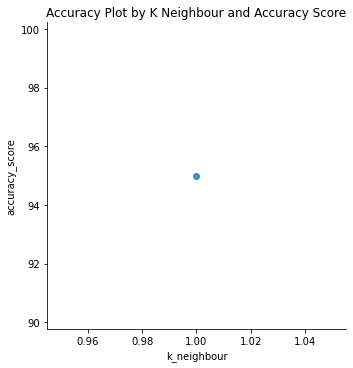

In [15]:
# Part 5 - 9
#

# Large Test Case
#
#

# This is the large test case based on:
#
#   - Prediction based on 1 k nearest neighbour,
#   - 10 test cases 
#   - training test size of 100.
#

# Set up the list of k nearest neighbours for the KNN model under test.
#
k_neighbours_list = [1]

# Set the ML training test size, the number of test cases with which each k 
# nearest neighbour will be tested.
#
training_test_size = 100
number_of_test_cases = 10

df = my_classifier.make_knn_predictions(k_neighbours_list, training_test_size, 
                                        number_of_test_cases)

# Display the dataframe.
#
print ("\n\n", df)

# Plot the dataframe using the k_neighbour and accuracy_score columns.
#
my_classifier.plot_scatter_plot('Accuracy Plot by K Neighbour and Accuracy Score', df, 'k_neighbour', 'accuracy_score', 'k_neighbour')

# Observation: as the training test size is increased (from 20 to 100), the accuracy 
# declines a little (in some tests, from 96.5% to 95.4%).  
# Increasing the training test size to 140 (maximum is 150) will decrease the accuracy 
# further to about 89%.  All of these accuracy numbers will differ based on each test run.
#


Examining K nearest neighbour 1
	Test 0 : Correct predictions = 20 / 20 Incorrect predictions = 0 Accuracy =  100.0
	Test 1 : Correct predictions = 19 / 20 Incorrect predictions = 1 Accuracy =  95.0
	Test 2 : Correct predictions = 19 / 20 Incorrect predictions = 1 Accuracy =  95.0
	Test 3 : Correct predictions = 18 / 20 Incorrect predictions = 2 Accuracy =  90.0
	Test 4 : Correct predictions = 20 / 20 Incorrect predictions = 0 Accuracy =  100.0
	Test 5 : Correct predictions = 20 / 20 Incorrect predictions = 0 Accuracy =  100.0
	Test 6 : Correct predictions = 19 / 20 Incorrect predictions = 1 Accuracy =  95.0
	Test 7 : Correct predictions = 20 / 20 Incorrect predictions = 0 Accuracy =  100.0
	Test 8 : Correct predictions = 19 / 20 Incorrect predictions = 1 Accuracy =  95.0
	Test 9 : Correct predictions = 19 / 20 Incorrect predictions = 1 Accuracy =  95.0
For K nearest neighbour 1 the average correct predictions is 19.3 / 20
For K nearest neighbour 1 the accuracy is 96.5 %

Examining K 

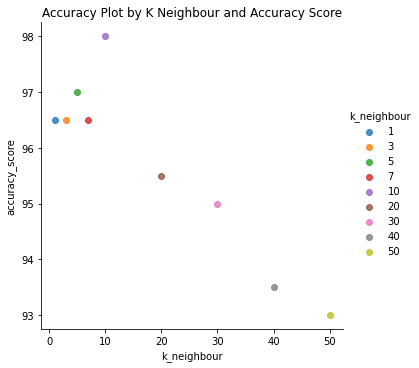

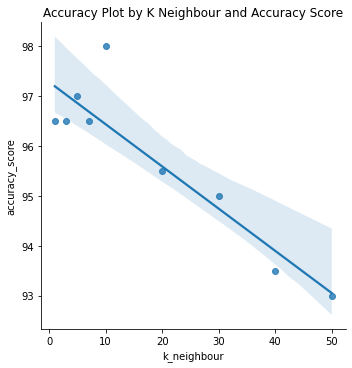

In [16]:
# Part 5 - 9
#

# Small Test Case
#
# This is the small test case based on:
#
#   - Prediction based on a set of k nearest neighbours,
#   - 10 test cases 
#   - training test size of 20.
#

# Set up the list of k nearest neighbours for the KNN model under test.
#
k_neighbours_list = [1, 3, 5, 7, 10, 20, 30, 40, 50]

# Set the ML training test size, the number of test cases with which each k 
# nearest neighbour will be tested.
#
training_test_size = 20
number_of_test_cases = 10

df = my_classifier.make_knn_predictions(k_neighbours_list, training_test_size, 
                                        number_of_test_cases)

# Display the dataframe of k neighbours and accuracy.
#
print ("\n\n", df)

# Plot the dataframe using the k_neighbour and accuracy_score columns.
#
my_classifier.plot_scatter_plot('Accuracy Plot by K Neighbour and Accuracy Score', df, 'k_neighbour', 'accuracy_score', 'k_neighbour')

# Observation: when the training_test_size is small (20), the predictability accuracy is
# very large (90 - 100%) but declines as more k neighbours are introduced.
#


Examining K nearest neighbour 1
	Test 0 : Correct predictions = 97 / 100 Incorrect predictions = 3 Accuracy =  97.0
	Test 1 : Correct predictions = 91 / 100 Incorrect predictions = 9 Accuracy =  91.0
	Test 2 : Correct predictions = 97 / 100 Incorrect predictions = 3 Accuracy =  97.0
	Test 3 : Correct predictions = 94 / 100 Incorrect predictions = 6 Accuracy =  94.0
	Test 4 : Correct predictions = 94 / 100 Incorrect predictions = 6 Accuracy =  94.0
	Test 5 : Correct predictions = 96 / 100 Incorrect predictions = 4 Accuracy =  96.0
	Test 6 : Correct predictions = 94 / 100 Incorrect predictions = 6 Accuracy =  94.0
	Test 7 : Correct predictions = 96 / 100 Incorrect predictions = 4 Accuracy =  96.0
	Test 8 : Correct predictions = 97 / 100 Incorrect predictions = 3 Accuracy =  97.0
	Test 9 : Correct predictions = 95 / 100 Incorrect predictions = 5 Accuracy =  95.0
For K nearest neighbour 1 the average correct predictions is 95.1 / 100
For K nearest neighbour 1 the accuracy is 95.1 %

Exami

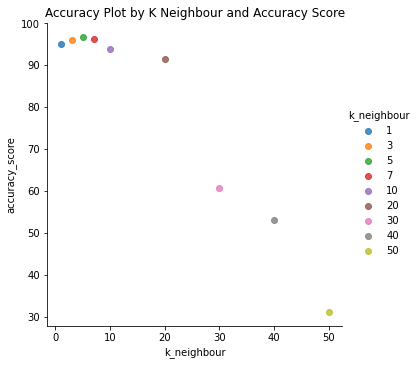

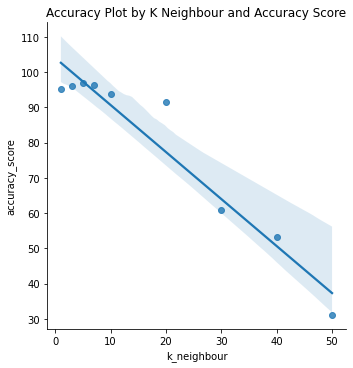

In [17]:
# Part 5 - 9
#

# This is the large test case based on:
#
#   - Prediction based on a set of k nearest neighbours,
#   - 10 test cases 
#   - training test size of 100.
#

# Prediction based on a list of k neighbours.
#

# Set up the list of k nearest neighbours for the KNN model under test.
#
k_neighbours_list = [1, 3, 5, 7, 10, 20, 30, 40, 50]

# Set the ML training test size, the number of test cases with which each k 
# nearest neighbour will be tested.
#
training_test_size = 100
number_of_test_cases = 10

df = my_classifier.make_knn_predictions(k_neighbours_list, training_test_size, 
                                        number_of_test_cases)

# Display the dataframe of k neighbours and accuracy.
#
print ("\n\n", df)

# Plot the dataframe using the k_neighbour and accuracy_score columns.
#
my_classifier.plot_scatter_plot('Accuracy Plot by K Neighbour and Accuracy Score', df, 'k_neighbour', 'accuracy_score', 'k_neighbour')

# Observation: when the training_test_size is large (100), the predictability accuracy declines
# from when the training test size was small (20).  More importantly, the more k nearest
# neighbours that are introduced, the larger the decrease in accuracy (regardless of the 
# training test size).  At k nearest neighbours = 50, the accuracy is ~31% compared to ~95%
# when the k nearest neighbours = 1.
#
